# Home Credit Default Risk Modeling

## Table of Contents

1. Introduction
2. Data Preperation
3. Establish a Performance Benchmark
4. Compare candidate models
5. Address class imbalance
6. Tune hyperparameters
7. Incorporate supplementary data
8. Kaggle Submission

## 1. Introduction

This notebook develops and evaluates predictive models to estimate the probability of loan default using the Kaggle Home Credit dataset.

First, a performance benchmark is established using a simple baseline model, and both accuracy and AUC are reported. Next, multiple candidate models are compared, including logistic regression and tree-based methods, using cross-validated out-of-sample AUC as the primary evaluation metric.

Because the target variable is highly imbalanced, ~8% default rate, strategies for addressing class imbalance are explored and performance is compared with and without adjustment. The best-performing model is then tuned using randomized search with 3-fold cross-validation on a subsample of the data to manage computational cost. Finally, the optimized model is trained on the full training dataset and used to generate predicted probabilities for Kaggle submission.

The cleaned and feature-engineered dataset used here was prepared separately in a data preparation notebook.

## 2. Data Preparation

The dataset used in this notebook was cleaned and feature-engineered in a separate data preparation notebook. The following steps were performed prior to modeling:

- Employment anomaly handling and imputation  
- EXT_SOURCE feature imputation and aggregation  
- Demographic and financial ratio feature engineering  
- Aggregation of bureau, previous application, and installment payment tables  
- One-hot encoding of categorical variables  
- Final imputation using training medians  
- Alignment of train and test feature columns  

The resulting dataset contains only numeric features and no missing values. The shape of the training and test sets are provided, along with the total number of features. The default rate is confirmed to be roughly 0.08, and it is furthmore confirmed that there are no missing values in the training or test set. 

In [1]:
import os
os.listdir()

['EDA.ipynb',
 'application_test.csv',
 '.DS_Store',
 'model_card.ipynb',
 'HomeCredit_columns_description.csv',
 'test_clean.parquet',
 'POS_CASH_balance.csv',
 'DataPrep.ipynb',
 'Modeling.ipynb',
 'train_clean.parquet',
 'credit_card_balance.csv',
 'installments_payments.csv',
 'application_train.csv',
 'README.md',
 'Modeling.html',
 'EDA.html',
 'bureau.csv',
 'home-credit-default-risk.zip',
 '.gitignore',
 '.ipynb_checkpoints',
 'data_preparation.py',
 '.git',
 'y_train.csv',
 'previous_application.csv',
 'bureau_balance.csv',
 'sample_submission.csv',
 'home-credit-default-risk']

In [2]:
# Import relevant packages
import pandas as pd
import numpy as np

# Load cleaned datasets
X = pd.read_parquet("train_clean.parquet")
X_test = pd.read_parquet("test_clean.parquet")
y = pd.read_csv("y_train.csv").squeeze()

print("Training shape:", X.shape)
print("Test shape:", X_test.shape)
print("Number of features:", X.shape[1])
print("Default rate:", round(y.mean(), 4))
print("Missing values (train):", X.isna().sum().sum())
print("Missing values (test):", X_test.isna().sum().sum())

Training shape: (307511, 243)
Test shape: (48744, 243)
Number of features: 243
Default rate: 0.0807
Missing values (train): 0
Missing values (test): 0


## 3. Establish a Performance Benchmark

Start with identifying the baseline accuracy which is established by the majority class classifier. The dataset has a high imbalance, with a majority class of non-deafult at a rate of 92%. The baseline accuracy and AUC are reported. 


In [3]:
# Import relevant packages
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# Training validation split
X_train, X_val, y_train_split, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize majority class classifier
dummy_model = DummyClassifier(strategy="most_frequent")

dummy_model.fit(X_train, y_train_split)

# Make predictions
y_val_pred = dummy_model.predict(X_val)
y_val_proba = dummy_model.predict_proba(X_val)[:, 1]

# Gather accuracy and auc metrics
dummy_accuracy = accuracy_score(y_val, y_val_pred)
dummy_auc = roc_auc_score(y_val, y_val_proba)

print("Dummy Accuracy:", dummy_accuracy)
print("Dummy AUC:", dummy_auc)

Dummy Accuracy: 0.9192722306228964
Dummy AUC: 0.5


The majority class classifier achieves high accuracy because a majority of applicants do not default. By simply predicting no default for every observation, the model is correct the majority of the time. However, this performance is misleading. The AUC of 0.5 indicates that the model has no ability to distinguish between those who default and those who do not. It assigns the same probability to each borrower, and performs no better than random guessing. This exemplifies why accuracy is not a reliable metric in this type of highly imbalanced classification problem. It will be neccessary to use AUC as the primary evaluation metric moving forward.

## 4. Compare candidate models
### 4.i Standard Logisitic Regression Model

Logistic regression is a standard baseline for binary classification problems with interpretable coefficients. Performance will be evaluated using accuracy and AUC metrics tested with the validation set. 

In [4]:
# Import
from sklearn.linear_model import LogisticRegression

# Initialize logistic regression
log_reg = LogisticRegression(max_iter=1000)

# Fit model
log_reg.fit(X_train, y_train_split)

# Predictions
y_val_pred_lr = log_reg.predict(X_val)
y_val_proba_lr = log_reg.predict_proba(X_val)[:, 1]

# Metrics
lr_accuracy = accuracy_score(y_val, y_val_pred_lr)
lr_auc = roc_auc_score(y_val, y_val_proba_lr)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Logistic Regression AUC:", lr_auc )

Logistic Regression Accuracy: 0.9192722306228964
Logistic Regression AUC: 0.6318403432253872


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


After running the initial logistic regression model, the overall accuracy remained unchanged at approximately 91.9%, which is expected given the strong class imbalance in the dataset. However, the AUC increased from 0.50 to 0.63. 

This improvement indicates that the model is now learning meaningful patterns in the data and is better able to distinguish between defaulters and non-defaulters. While the predictive strength is still slight, the increase in AUC confirms that the model has begun to capture useful signal beyond the majority class baseline.

### 4.ii Logistic Regression (class-weighted)

In this section, logistic regression is re-ran using class weighting to address the strong class imbalance, which under-represents the prevalance of data on the minority class during training. By adding the feature, `class_weight="balanced"`, the model prioritizes the minority class during training.
 Performance will again be evaluated using AUC as the primary metric.

In [5]:
# Initialize class-weighted logistic regression
log_reg_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

# Fit model
log_reg_balanced.fit(X_train, y_train_split)

# Predictions
y_val_pred_bal = log_reg_balanced.predict(X_val)
y_val_proba_bal = log_reg_balanced.predict_proba(X_val)[:, 1]

# Metrics
balanced_accuracy = accuracy_score(y_val, y_val_pred_bal)
balanced_auc = roc_auc_score(y_val, y_val_proba_bal)

print("Balanced Logistic Regression Accuracy:", balanced_accuracy)
print("Balanced Logistic Regression AUC:", balanced_auc)

Balanced Logistic Regression Accuracy: 0.6094662049005739
Balanced Logistic Regression AUC: 0.6185350194650252


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


When the above class weighting was introduced into the logistic regression model, the AUC decreased slightly from 0.63 to 0.62. Class weighting increased the penalty on accuracy when misclassifying defaulters. Furthermore, it did not improve the model’s ability to rank borrowers by risk in this case.

These results may suggest that the first logistic regression was already capturing most of the linearity in the data, since additional weighting did not enhance discriminatory performance. Although class imbalance is substantial, imbalance adjustment does not always lead to improved AUC, particularly when evaluating a model's ranking performance. 

### 4.iv Cross-Validated Model Comparison

For a more reliable estimate of out-of-sample performance, 5-fold stratified cross-validation is used. Unlike a single train-validation split, cross-validation evaluates model performance across multiple subsets of the data, reducing sensitivity to any one particular split and reducing the degree of overfitting.

Four different models(log regression, log regression with class balancing, random forest, and gradient boosting) are compared using mean cross-validated AUC, which is the primary evaluation metric in this imbalanced classification problem.

In [6]:
# Import relevant packages
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Define stratified 5-fold cross-validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Logistic Regression (Balanced)": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=50,
        random_state=42
    )
}

# Store cross-validated results
cv_results = {}

print("Cross-Validated AUC Results:\n")

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="roc_auc"
    )
    
    cv_results[name] = scores.mean()
    
    print(f"{name}:")
    print(f"  Fold AUCs: {scores}")
    print(f"  Mean AUC: {scores.mean():.4f}")
    print(f"  Std Dev: {scores.std():.4f}\n")

Cross-Validated AUC Results:



/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please a

Logistic Regression:
  Fold AUCs: [0.63021803 0.63073715 0.62946262]
  Mean AUC: 0.6301
  Std Dev: 0.0005



/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please a

Logistic Regression (Balanced):
  Fold AUCs: [0.61154505 0.6195092  0.61430294]
  Mean AUC: 0.6151
  Std Dev: 0.0033

Random Forest:
  Fold AUCs: [0.71790869 0.71525018 0.70628123]
  Mean AUC: 0.7131
  Std Dev: 0.0050

Gradient Boosting:
  Fold AUCs: [0.75261036 0.7548265  0.74840835]
  Mean AUC: 0.7519
  Std Dev: 0.0027



The above results show the comparison of AUC metrics betweent the four models. The standard logistic regression model had a mean AUC of 0.63, showing limited predictive performance. The class-weighted logistic regression performed slightly worse, with a mean AUC of 0.615, suggesting that weighting the classes did not improve discrimination.

The Random Forest model and Gradient Boosting model substantially outperformed both of the logistic regression models, reaching a mean AUC of 0.713 and 0.75 respectivelly. These models showed a much better ability to distinguish between defaulters and non-defaulters. 

So far, the Gradient Boosting model has provided the best performance in AUC among the four models evaluated. 

## 5. Address class imbalance


Although Gradient Boosting achieved the highest AUC among the tested models, the heavy class imbalance (~92% majority) may continue to limit the model’s ability to accurately learn patterns associated with the minority class.

To address this, I will apply Synthetic Minority Oversampling Technique (SMOTE), which generates synthetic instances of the minority class to create a more balanced training dataset. This model will then be evaluated using cross-validated AUC and compared to the original (non-resampled) Gradient Boosting performance.

In [7]:
# Import relevant packages
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Intialize cross-validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Create pipeline: SMOTE applied inside each fold
smote_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", GradientBoostingClassifier(
        n_estimators=50,
        random_state=42
    ))
])

# Run cross-validation
smote_scores = cross_val_score(
    smote_pipeline,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

# Print results
print("Gradient Boosting with SMOTE:")
print("Fold AUCs:", smote_scores)
print("Mean AUC:", smote_scores.mean())
print("Std Dev:", smote_scores.std())

Gradient Boosting with SMOTE:
Fold AUCs: [0.70307141 0.70423972 0.7015001 ]
Mean AUC: 0.702937079273196
Std Dev: 0.0011224713145329657


To address the class imbalance, SMOTE oversampling was applied prior to training a Gradient Boosting model. The resulting mean AUC decreased from 0.752 to 0.703. This indicates that oversampling did not improve discriminatory performance. The Gradient Boosting model appears to handle class imbalance effectively without synthetic resampling, and SMOTE may have introduced additional noise that reduced ranking performance. 

## 6. Tune hyperparameters

To improve model performance further, hyperparameter tuning was conducted on the best-performing model, Gradient Boosting. One of the largest setbacks observed up until this point has been the computational cost. Using the entire dataset to tune the model was costly both in time and space. 

For the purpose of fine parameeter tuning, a stratified subsample of 5,000 observations was used to slightly simplify things the cross-validation only used 3 folds. Randomized search was selected instead of exhaustive grid search to efficiently explore the hyperparameter space. And after the optimal parameters were uncovered, the final model will be retrained on the full training dataset.

In [8]:
# Import relevant packages
from sklearn.model_selection import train_test_split

# New train test split with only 5000 observations
X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train_split,
    train_size=5000,
    stratify=y_train_split,
    random_state=42
)

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import numpy as np

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Define the search space for param tuning
param_dist = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": np.linspace(0.01, 0.2, 10),
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Initialize the model
gb = GradientBoostingClassifier(random_state=42)

# Hyperparam tuning engine
random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist,
    n_iter=20,             
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_tune, y_tune)

print("\nBest Cross-Validated AUC (Subset):", random_search.best_score_)
print("Best Parameters:", random_search.best_params_)
best_params = random_search.best_params_

final_model = GradientBoostingClassifier(
    **best_params,
    random_state=42
)

# Train only on training data
final_model.fit(X_train, y_train_split)

from sklearn.metrics import roc_auc_score

y_val_proba = final_model.predict_proba(X_val)[:, 1]
final_val_auc = roc_auc_score(y_val, y_val_proba)

print("Final Validation AUC (Tuned Model):", final_val_auc)


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Cross-Validated AUC (Subset): 0.7098872418201037
Best Parameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 2, 'learning_rate': np.float64(0.03111111111111111)}
Final Validation AUC (Tuned Model): 0.7245419500050533


The final Gradient Boosting model retrained on the full training dataset using the updated parameters and evaluated on the validation set. The resulting validation AUC was 0.7245.

Although this validation AUC is slightly lower than the earlier cross-validated AUC of approximately 0.75 reported for the untuned model, the two scores are not directly comparable because they were obtained using different evaluation procedures (cross-validation vs a single hold-out validation split). Overall, hyperparameter tuning did not produce a clear improvement in performance, suggesting that the default configuration of Gradient Boosting was already appropriate for this dataset.

## 7. Incorporate supplementary data

To enhance model performance beyond the base application features, the extra behavioral data were incorporated from bureau.csv, previous_application.csv, and installments_payments.csv. These external tables contain historical credit and repayment information that provide additional insight into an applicant’s financial behavior.

Each supplementary dataset was aggregated to the applicant level using SK_ID_CURR as the key. From the bureau data, features such as the total number of prior credits (BUREAU_COUNT), mean outstanding debt (BUREAU_MEAN_DEBT), and number of active credits (BUREAU_ACTIVE_COUNT) were constructed. From previous applications, the total number of past applications (PREV_APP_COUNT) and historical approval rate (PREV_APPROVAL_RATE) were computed. From installment payment records, behavioral indicators including average payment delay (MEAN_PAYMENT_DELAY) and proportion of late payments (LATE_PAYMENT_RATE) were engineered.

These aggregated features were merged into the main application dataset and included in all subsequent modeling steps. By incorporating historical credit exposure and repayment behavior, the model leverages richer behavioral signals that are not available in the static application data alone.

All model performance results reported in this notebook are based on the cleaned dataset which previously includer these supplementary engineered features.

## 8. Kaggle Submission

Now it is time to generate the Kaggle submission and see what the 


In [9]:
# Save test ids
test_ids = X_test['SK_ID_CURR']

# Remove id from training and test
X_model = X.drop(columns=['SK_ID_CURR'])
X_test_model = X_test.drop(columns=['SK_ID_CURR'])

final_model = GradientBoostingClassifier(
    **best_params,
    random_state=42
)

# Fit the model
final_model.fit(X_model, y)

test_proba = final_model.predict_proba(X_test_model)[:, 1]

submission = pd.DataFrame({
    "SK_ID_CURR": test_ids,
    "TARGET": test_proba
})

# Save to file
submission.to_csv("kaggle_submission.csv", index=False)

print("Submission file created.")



Submission file created.


After submitting this file into Kaggle, the score that I received was a private submission score of 0.70 and a public score of 0.72. The public score is consistent with the validation AUC (~0.72–0.75), suggesting that the model generalizes somewhat well, although there is a slight drop on the private leaderboard, indicating some mild overfitting.

In [11]:
# Extra Test Metrics for Final Model 

from sklearn.metrics import roc_auc_score, precision_score, recall_score, confusion_matrix

# Use YOUR trained model
y_pred_proba = final_model.predict_proba(X_model)[:, 1]

# Choose threshold
threshold = 0.5
y_pred = (y_pred_proba >= threshold).astype(int)

# Metrics
auc = roc_auc_score(y, y_pred_proba)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)

# Confusion matrix
cm = confusion_matrix(y, y_pred)

print("=== FINAL MODEL PERFORMANCE ===")
print(f"AUC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("\nConfusion Matrix:")
print(cm)

=== FINAL MODEL PERFORMANCE ===
AUC: 0.7253
Precision: 0.0000
Recall: 0.0000

Confusion Matrix:
[[282686      0]
 [ 24825      0]]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [12]:
print("Min prob:", y_pred_proba.min())
print("Max prob:", y_pred_proba.max())
print("Mean prob:", y_pred_proba.mean())

Min prob: 0.0418975908569016
Max prob: 0.30745235514758223
Mean prob: 0.08083225776392727


In [15]:
threshold = 0.15
y_pred = (y_pred_proba >= threshold).astype(int)

precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)

cm = confusion_matrix(y, y_pred)

print("=== THRESHOLD = 0.2 ===")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(cm)

=== THRESHOLD = 0.2 ===
Precision: 0.2424
Recall: 0.2835
[[260696  21990]
 [ 17788   7037]]


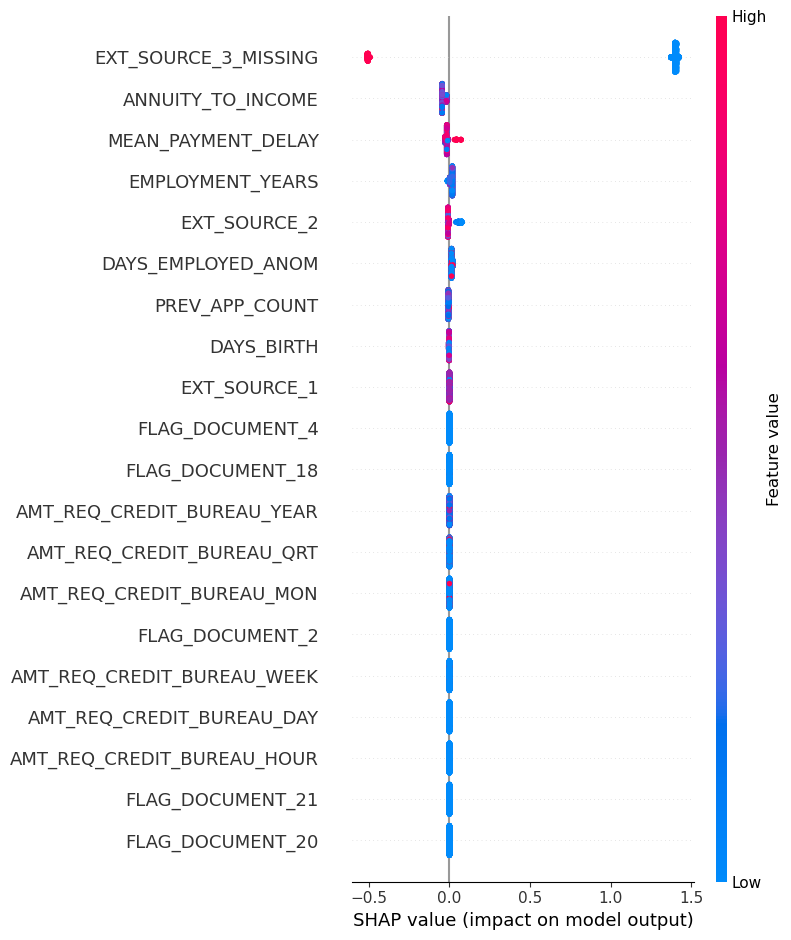

In [21]:
import shap

X_sample = X_val.sample(1000, random_state=42)
X_sample = X_sample.apply(pd.to_numeric, errors='coerce').fillna(0)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

In [29]:
original_df = pd.read_csv("application_train.csv")

In [30]:
# Fairness Analysis 
# Step 1: make sure X_val matches training features
X_val_model = X_val.drop(columns=['SK_ID_CURR'], errors='ignore')

# Step 2: recompute predictions correctly
threshold = 0.15
y_pred_proba_val = final_model.predict_proba(X_val_model)[:, 1]
y_pred = (y_pred_proba_val >= threshold).astype(int)

# Step 3: fairness dataframe
df_fairness = X_val.copy()
df_fairness['prediction'] = y_pred

# Step 4: align original data
df_subset = original_df.loc[X_val.index]

df_fairness['CODE_GENDER'] = df_subset['CODE_GENDER']
df_fairness['NAME_EDUCATION_TYPE'] = df_subset['NAME_EDUCATION_TYPE']

gender_approval = df_fairness.groupby('CODE_GENDER')['prediction'].apply(lambda x: (x == 0).mean())
print(gender_approval)

edu_approval = df_fairness.groupby('NAME_EDUCATION_TYPE')['prediction'].apply(lambda x: (x == 0).mean())
print(edu_approval)

CODE_GENDER
F      0.917211
M      0.886676
XNA    0.500000
Name: prediction, dtype: float64
NAME_EDUCATION_TYPE
Academic degree                  0.850000
Higher education                 0.930084
Incomplete higher                0.868712
Lower secondary                  0.887484
Secondary / secondary special    0.900901
Name: prediction, dtype: float64
